# PyFC Quickstart: Binned and Unbinned Models

This notebook is the runnable, narrated counterpart to the README's **Quick Start Guide**
-- the same two models (binned and unbinned), executed end-to-end with real Feldman-Cousins
output, instead of just showing the code.

PyFC needs you to supply a `compute_rates_func`: a small function mapping your physical
parameters to the expected data (bin counts, or an event-by-event density). Everything else
-- the profile-likelihood scan, the Monte Carlo toy generation, the confidence-interval
construction -- is handled by `compute_fc_intervals`.

We keep `n_toys` and the parameter grids deliberately small here so the whole notebook runs
in well under a minute; for a real analysis you'd use hundreds to thousands of toys and a
much finer grid (see the "How many toys should I use?" FAQ in the README).

This notebook covers:
1. **Binned model** -- fixed MC templates, Poisson counts.
2. **Unbinned model** -- event-by-event PDFs, parametric bootstrap toys.

For other topics (many-parameter scaling, sparsification/smoothing/finite-MC knobs, and
optimizer-strategy comparisons), see the sibling notebooks in this directory.

In [1]:
%matplotlib inline

import numpy as np
from numba import njit
from scipy.stats import expon, norm

from pyfc import compute_fc_intervals, generate_corner_plot

np.random.seed(20260727)

N_TOYS = 25   # Kept small so this notebook runs quickly; use >=500 for real analyses.
CORES = 2


def print_1d_bounds(results, n_params, cl_list):
    """Extract and print the 1D interval bounds directly from an in-memory `results` dict."""
    for p_idx in range(n_params):
        test_pts = results[f"1d_test_p{p_idx+1}"]
        print(f"  param{p_idx+1}:")
        for cl in cl_list:
            accepted = results[f"1d_accepted_p{p_idx+1}"][cl]
            accepted_pts = test_pts[accepted]
            if len(accepted_pts) == 0:
                print(f"    CL {cl}: no accepted points (empty interval)")
            else:
                print(f"    CL {cl}: [{accepted_pts.min():.4g}, {accepted_pts.max():.4g}]")

Numba detected: JIT compilation enabled for maximum speed.


## 1. Binned model

For a binned analysis, fixed MC templates are ordinary NumPy arrays referenced via **closure**
(module-level constants, in this case) from `compute_rates_func` -- they are *not* passed in
as function arguments. `compute_rates_func` itself only ever sees the physics parameters plus
the per-bin sum-of-squared-MC-weights arrays (`S_sumw2`/`B_sumw2`), and must return the
expected bin counts $\mu$ and their variance $\sigma^2$.

Our toy model has 4 bins and 3 free parameters:
* `params[0]` = flux normalization
* `params[1]` = spectral index (multiplies the signal template together with the normalization)
* `params[2]` = background normalization

so $\mu = (\text{flux\_norm} \times \text{spectral\_index}) \times S + \text{bg\_norm} \times B$.

Running 3-parameter binned analysis...



--- 1D interval bounds (binned) ---
  param1:
    CL 0.68: [0.5, 0.5]
    CL 0.9: [0.5, 0.5]
  param2:
    CL 0.68: [0.5, 0.5]
    CL 0.9: [0.5, 0.5]
  param3:
    CL 0.68: [1.214, 1.5]
    CL 0.9: [1.071, 1.5]

Global best fit: [0.5        0.5        1.34142425]


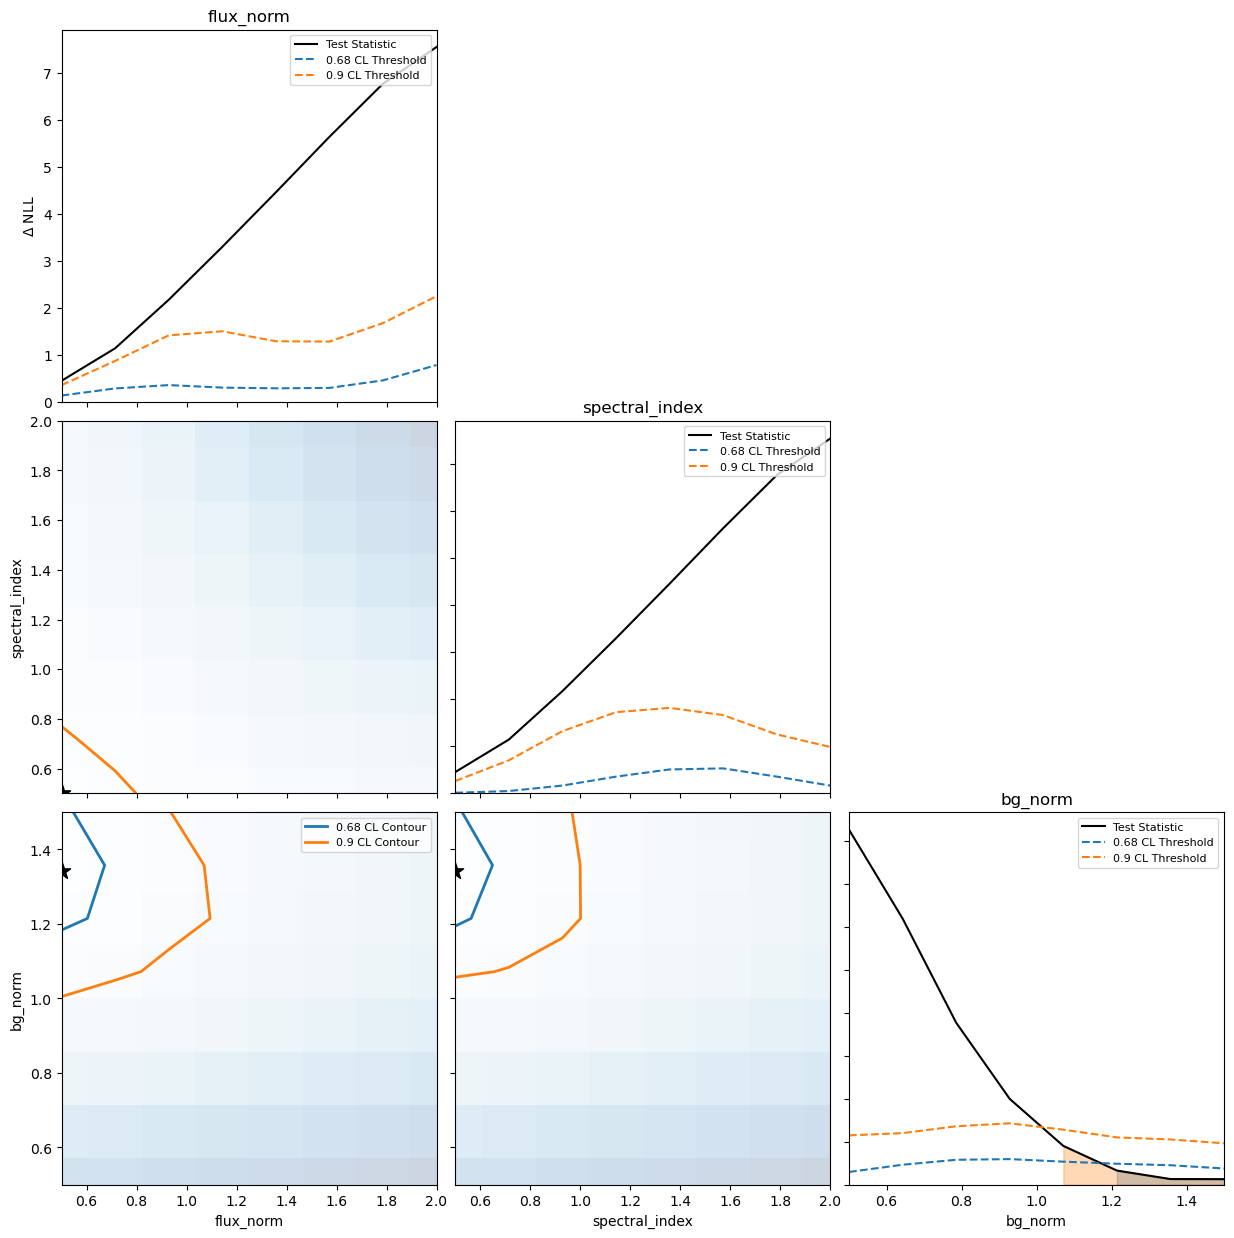

In [2]:
# Fixed MC templates, referenced via closure (not passed as compute_rates_func arguments).
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
ZERO_SUMW2 = np.zeros_like(S_template)   # "infinite MC statistics" -- disables the finite-MC correction


@njit(fastmath=True, nogil=True)
def compute_rates_binned(params, S_sumw2, B_sumw2):
    """ Maps (flux_norm, spectral_index, bg_norm) to expected bin counts (mu) and variances (sigma2). """
    mu = (params[0] * params[1]) * S_template + params[2] * B_template
    sigma2 = ((params[0] * params[1])**2) * S_sumw2 + (params[2]**2) * B_sumw2
    return mu, sigma2


grids_binned = [np.linspace(0.5, 2.0, 8), np.linspace(0.5, 2.0, 8), np.linspace(0.5, 1.5, 8)]
observed_counts = np.array([20, 7, 2, 0])

print("Running 3-parameter binned analysis...")
results_binned, fig_binned = compute_fc_intervals(
    data=observed_counts,
    grids=grids_binned,
    compute_rates_func=compute_rates_binned,
    likelihood_type="binned",
    S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    param_names=["flux_norm", "spectral_index", "bg_norm"],
    save_directory="quickstart_output/binned",
)

print("\n--- 1D interval bounds (binned) ---")
print_1d_bounds(results_binned, n_params=3, cl_list=[0.68, 0.90])
print("\nGlobal best fit:", results_binned["best_fit"])

## 2. Unbinned model

For unbinned data, `pdf_components` is a **list** of PDF functions -- one per model component
(signal, background, ... any number, not just two). Each is evaluated exactly once per fit as
`pdf(data)`, and the resulting arrays are reused across every subsequent NLL evaluation -- this
caching is why PyFC asks for a *list of PDFs* rather than one pre-combined density (the
relative signal/background weighting is itself a free fit parameter, so the combination can't
be precomputed once and for all).

`compute_rates_func` receives the pre-evaluated densities as a `probs` list (`probs[0]` is
`pdf_components[0]` evaluated on the data, and so on) and must return the total expected event
count and the per-event mixture density.

Running 2-parameter unbinned analysis...



--- 1D interval bounds (unbinned) ---
  param1:
    CL 0.68: [3, 5]
    CL 0.9: [3, 7]
  param2:
    CL 0.68: [3, 3]
    CL 0.9: [1, 7]

Global best fit: [4.72071892 2.27927487]


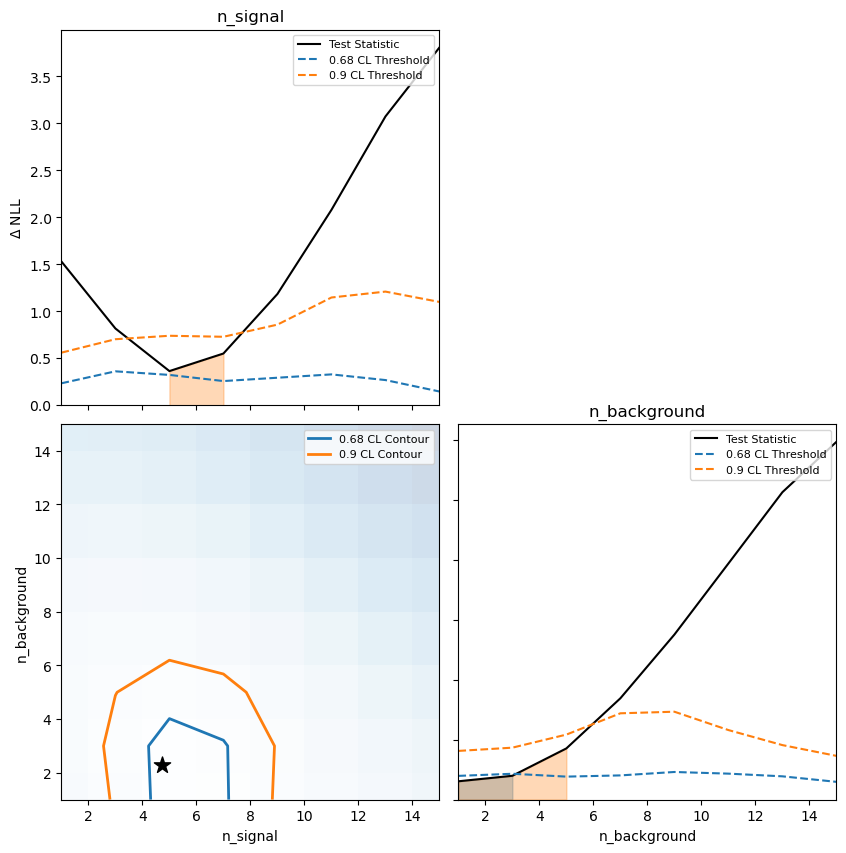

In [3]:
# PDF definitions: signal is Gaussian-distributed, background is exponential.
def s_pdf(x): return norm.pdf(x, loc=5.0, scale=1.0)
def b_pdf(x): return expon.pdf(x, scale=2.0)


def compute_rates_unbinned(params, probs):
    """ Returns the total expected event count and the per-event mixture density. """
    s_probs, b_probs = probs[0], probs[1]
    expected_total = params[0] + params[1]
    if len(s_probs) == 0:
        return expected_total, np.array([])
    p_events = params[0] * s_probs + params[1] * b_probs
    return expected_total, p_events


def generate_toy(true_params, s_mc_pool, b_mc_pool):
    """ Parametric bootstrap: draw Poisson-distributed counts from each component, then
    resample events from the corresponding MC pool. Index-based resampling (not
    np.random.choice directly on the pool) is required for N-D event feature vectors;
    here events are scalar (1D), so either works, but we use the general-purpose form. """
    n_sig = np.random.poisson(true_params[0])
    n_bkg = np.random.poisson(true_params[1])
    idx_s = np.random.choice(len(s_mc_pool), size=n_sig, replace=True)
    idx_b = np.random.choice(len(b_mc_pool), size=n_bkg, replace=True)
    return np.concatenate([s_mc_pool[idx_s], b_mc_pool[idx_b]])


s_mc_pool = np.random.normal(5.0, 1.0, 3000)
b_mc_pool = np.random.exponential(2.0, 3000)
observed_events = np.concatenate([np.random.choice(s_mc_pool, 4), np.random.choice(b_mc_pool, 3)])

grids_unbinned = [np.linspace(1.0, 15.0, 8), np.linspace(1.0, 15.0, 8)]

print("Running 2-parameter unbinned analysis...")
results_unbinned, fig_unbinned = compute_fc_intervals(
    data=observed_events,
    grids=grids_unbinned,
    compute_rates_func=compute_rates_unbinned,
    generate_toy_func=generate_toy,
    pdf_components=[s_pdf, b_pdf],
    likelihood_type="unbinned",
    S_mc_pool=s_mc_pool, B_mc_pool=b_mc_pool,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    verbose=0,
    sparsify_grid=False,
    param_names=["n_signal", "n_background"],
    save_directory="quickstart_output/unbinned",
)

print("\n--- 1D interval bounds (unbinned) ---")
print_1d_bounds(results_unbinned, n_params=2, cl_list=[0.68, 0.90])
print("\nGlobal best fit:", results_unbinned["best_fit"])

## Next steps

* **`pyfc_high_dimensional_tutorial.ipynb`** -- scaling to many free parameters (5 and 10),
  and the combinatorial cost of 2D contours.
* **`pyfc_algorithmic_features_tutorial.ipynb`** -- the `sparsify_grid`, `smooth_1d`/`smooth_2d`,
  and `use_finite_mc_correction_binned` knobs.
* **`pyfc_strategy_comparison_tutorial.ipynb`** -- comparing the `"grid"`/`"scipy"`/`"hybrid"`
  optimizer strategies, and building custom plots from PyFC's saved `.json`/`.npz` output.
* **`pyfc_joint_constraints_tutorial.ipynb`** -- handling joint/simplex constraints between
  parameters (e.g. `f_e + f_mu <= 1`) via `bounds_func`/`constraints`.
* **`pyfc_non_contiguous_data_tutorial.ipynb`** -- passing non-contiguous (e.g.
  transposed) N-D `data` arrays straight into `compute_fc_intervals`.
